# Car Price Prediction with Machine Learning
**Track:** Data Science &nbsp;|&nbsp; **Task 3**

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Dataset:** Download the "Vehicle dataset from cardekho" from Kaggle (search "car price prediction dataset") and save it as `car_data.csv` in the same folder as this notebook. If the file isn't found, a synthetic dataset with the same schema is generated automatically so the full pipeline still runs end-to-end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load the dataset

In [2]:
import os

DATA_PATH = "car_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Loaded real dataset from", DATA_PATH)
else:
    print("car_data.csv not found - generating a synthetic dataset with the same schema.")
    n = 400
    brands = ["Maruti", "Hyundai", "Honda", "Toyota", "Tata", "Ford"]
    fuel_types = ["Petrol", "Diesel", "petrol", "diesel", "CNG"]
    transmissions = ["Manual", "Automatic"]

    car_name = np.random.choice(brands, n)
    year = np.random.randint(2005, 2023, n)
    present_price = np.round(np.random.uniform(3, 25, n), 2)
    kms_driven = np.random.randint(1000, 150000, n)
    fuel_type = np.random.choice(fuel_types, n)
    seller_type = np.random.choice(["Dealer", "Individual"], n)
    transmission = np.random.choice(transmissions, n)
    owner = np.random.choice([0, 1, 2, 3], n, p=[0.7, 0.2, 0.07, 0.03])

    age = 2024 - year
    depreciation = present_price * (0.92 ** age)
    km_penalty = kms_driven / 100000 * 0.5
    selling_price = np.clip(
        depreciation - km_penalty + np.random.normal(0, 0.5, n), 0.1, None
    )

    df = pd.DataFrame({
        "Car_Name": car_name, "Year": year, "Selling_Price": np.round(selling_price, 2),
        "Present_Price": present_price, "Kms_Driven": kms_driven, "Fuel_Type": fuel_type,
        "Seller_Type": seller_type, "Transmission": transmission, "Owner": owner
    })

df.head()

car_data.csv not found - generating a synthetic dataset with the same schema.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Toyota,2011,4.03,13.97,126341,CNG,Individual,Automatic,0
1,Tata,2008,0.96,4.91,30430,CNG,Individual,Automatic,0
2,Honda,2017,7.82,14.82,28788,petrol,Individual,Automatic,0
3,Tata,2005,2.63,15.91,145991,CNG,Dealer,Automatic,1
4,Tata,2012,7.01,19.40,70346,Petrol,Individual,Automatic,0


## 2. Data cleaning

In [3]:
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates()

# Normalise inconsistent categorical casing, e.g. "Petrol" vs "petrol"
df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
df["Transmission"] = df["Transmission"].str.strip().str.title()
if "Seller_Type" in df.columns:
    df["Seller_Type"] = df["Seller_Type"].str.strip().str.title()

print("\nUnique fuel types after cleaning:", df["Fuel_Type"].unique())

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Unique fuel types after cleaning: <StringArray>
['Cng', 'Petrol', 'Diesel']
Length: 3, dtype: str


## 3. Feature engineering: car age and brand

In [4]:
CURRENT_YEAR = 2024
df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Extract brand as the first word of the car name (covers real Kaggle naming like "ritz", "swift dzire")
df["Brand"] = df["Car_Name"].astype(str).str.split().str[0].str.title()

df[["Car_Name", "Brand", "Year", "Car_Age"]].head()

,Car_Name,Brand,Year,Car_Age
0,Toyota,Toyota,2011,13
1,Tata,Tata,2008,16
2,Honda,Honda,2017,7
3,Tata,Tata,2005,19
4,Tata,Tata,2012,12


## 4. EDA

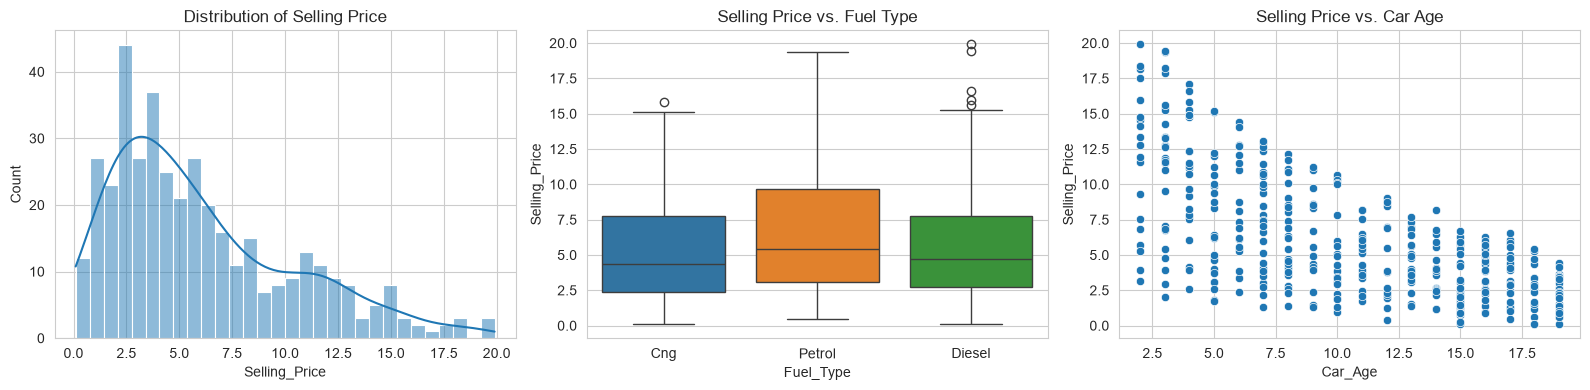

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["Selling_Price"], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Distribution of Selling Price")

sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", legend=False, ax=axes[1])
axes[1].set_title("Selling Price vs. Fuel Type")

sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", ax=axes[2])
axes[2].set_title("Selling Price vs. Car Age")

plt.tight_layout()
plt.show()

## 5. Encode categorical variables

In [6]:
categorical_cols = [c for c in ["Fuel_Type", "Seller_Type", "Transmission", "Brand"] if c in df.columns]
numeric_cols = [c for c in ["Present_Price", "Kms_Driven", "Owner", "Car_Age"] if c in df.columns]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

df_encoded = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)
df_encoded["Selling_Price"] = df["Selling_Price"].values
df_encoded.head()

Categorical columns: ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']
Numeric columns: ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']


,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Honda,Brand_Hyundai,Brand_Maruti,Brand_Tata,Brand_Toyota,Selling_Price
0,13.97,126341,0,13,False,False,True,False,False,False,False,False,True,4.03
1,4.91,30430,0,16,False,False,True,False,False,False,False,True,False,0.96
2,14.82,28788,0,7,False,True,True,False,True,False,False,False,False,7.82
3,15.91,145991,1,19,False,False,False,False,False,False,False,True,False,2.63
4,19.40,70346,0,12,False,True,True,False,False,False,False,True,False,7.01


## 6. Feature correlation heatmap

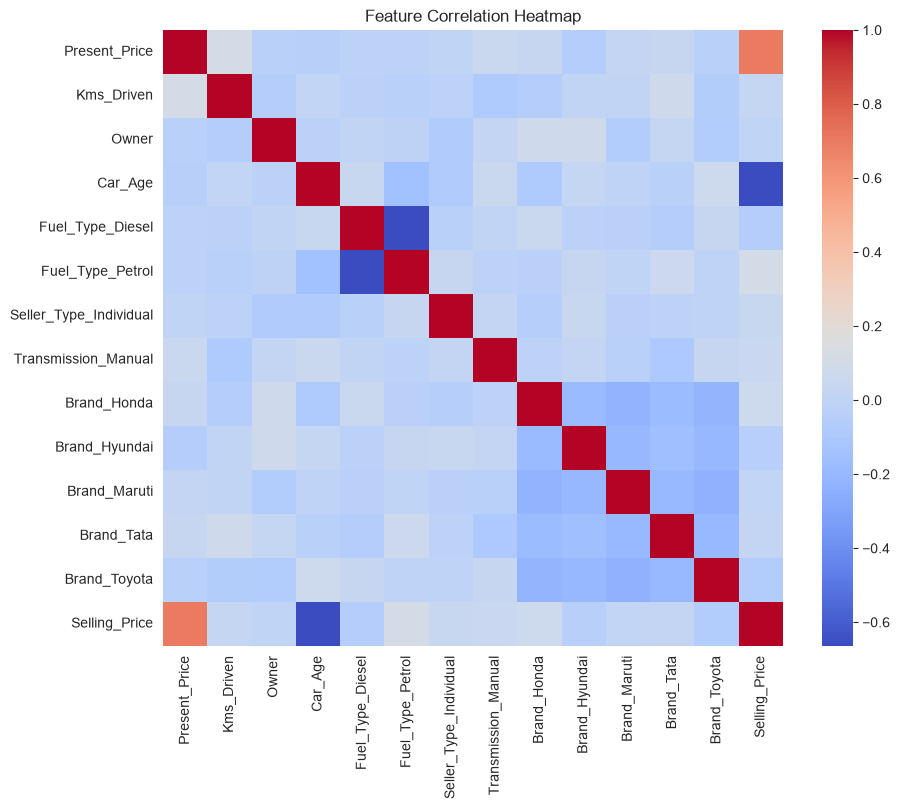

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## 7. Train/test split

In [8]:
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (320, 13)  Test shape: (80, 13)


## 8. Train regression models

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_test)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
gb_preds = gb_reg.predict(X_test)

models = {
    "Linear Regression": lin_preds,
    "Random Forest": rf_preds,
    "Gradient Boosting": gb_preds,
}

## 9. Evaluate models: MAE, RMSE, R²

In [10]:
for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

Linear Regression: MAE=1.133  RMSE=1.440  R2=0.896
Random Forest: MAE=0.609  RMSE=0.762  R2=0.971
Gradient Boosting: MAE=0.499  RMSE=0.635  R2=0.980


## 10. Feature importance for the best-performing model

Best-performing model: Gradient Boosting


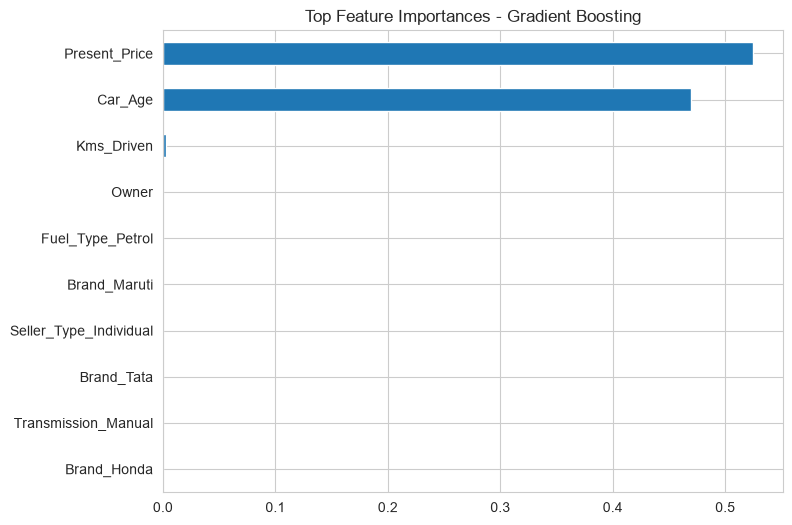

Present_Price             0.525076
Car_Age                   0.469823
Kms_Driven                0.003084
Owner                     0.000465
Fuel_Type_Petrol          0.000464
Brand_Maruti              0.000248
Seller_Type_Individual    0.000211
Brand_Tata                0.000198
Transmission_Manual       0.000188
Brand_Honda               0.000104
dtype: float64

In [11]:
best_name = max(models, key=lambda k: r2_score(y_test, models[k]))
print("Best-performing model:", best_name)

best_model = {"Linear Regression": lin_reg, "Random Forest": rf_reg, "Gradient Boosting": gb_reg}[best_name]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind="barh")
plt.title(f"Top Feature Importances - {best_name}")
plt.gca().invert_yaxis()
plt.show()

importances.head(10)

## Conclusion

We cleaned the raw car listing data (fixing inconsistent casing and handling
duplicates), engineered car age and brand features, explored price
distributions and relationships with fuel type and age, encoded categorical
variables, and trained three regression models. The best-performing model was
identified using MAE/RMSE/R², and its feature importances confirm that
present price and car age are the strongest predictors of resale value,
consistent with how depreciation works in practice.